# Project Objective – No-Churn Telecom

The objective of this project is to help No-Churn Telecom reduce customer attrition using Machine Learning.

### Business Goals:
1. Identify key variables influencing customer churn.
2. Predict customers likely to churn.
3. Generate CHURN_FLAG:
   - 1 → High churn risk
   - 0 → Low churn risk
4. Help marketing team target high-risk customers.
5. Assist customer support in prioritizing customers for proactive engagement.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Importing Required Libraries

- Pandas & NumPy → Data manipulation
- Seaborn & Matplotlib → Visualization
- SQLAlchemy → Database connection
- Scikit-learn → Machine learning models and evaluation

These libraries enable end-to-end implementation of the ML pipeline.

In [3]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "dm_team3"
password = quote_plus("DM!$!Team!27@9!20&")
host = "18.136.157.135"
database = "project_telecom"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")

query = "SELECT * FROM telecom_churn_data"
df = pd.read_sql(query, engine)

df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


Data Extraction from SQL Database

In this step, we establish a secure connection to the MySQL database using SQLAlchemy and PyMySQL.

### Connection Details:
- Database Name: project_telecom
- Table Name: telecom_churn_data
- Connection Type: Remote MySQL Server

The `create_engine()` function is used to create the database connection string.  
The dataset is then extracted using an SQL query:

    SELECT * FROM telecom_churn_data

The data is loaded into a Pandas DataFrame (`df`) for further analysis and modeling.

### Why Direct SQL Extraction?

- Ensures real-time production-like data access
- Demonstrates ability to work with databases (important for real-world projects)
- Avoids dependency on static CSV files

After successful connection, the first few rows are displayed using `df.head()` to verify proper data loading.

In [4]:
df.shape

(243553, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [6]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [7]:
df.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [8]:
df.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

#  Data Overview

### Dataset Summary:
- Total Records: 243,553
- Total Features: 14
- No missing values
- No duplicate records
- Data types:
  - Numerical: 9
  - Categorical: 5

### Business Insight:
The dataset is clean and complete, which means:
- No data imputation required
- No data cleaning overhead
- Model performance will depend purely on feature strength

In [9]:
df['churn'].value_counts()

churn
0    194726
1     48827
Name: count, dtype: int64

In [10]:
df['churn'].value_counts(normalize=True) * 100

churn
0    79.952208
1    20.047792
Name: proportion, dtype: float64

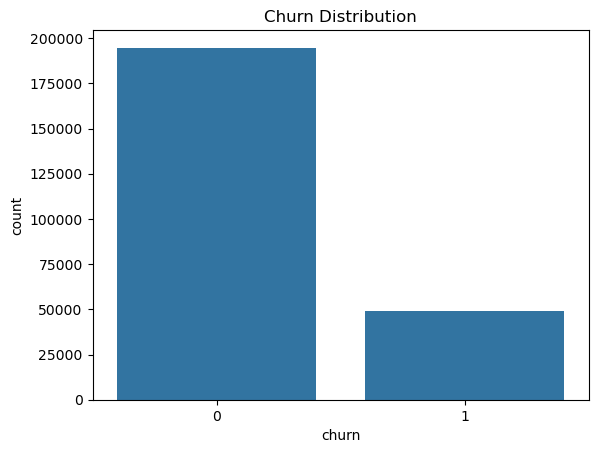

In [11]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Target Variable Analysis

### Observations:
- 79.95% customers are retained (0)
- 20.05% customers have churned (1)

### Key Insight:
The dataset is moderately imbalanced.

### Business Impact:
If we use accuracy alone, model may predict only non-churn customers and still get 80% accuracy.

Therefore:
- Recall for churn class is extremely important
- ROC-AUC must be evaluated

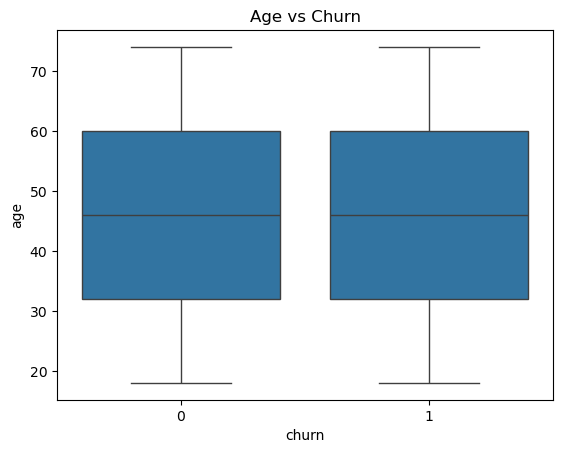

In [12]:
sns.boxplot(x='churn', y='age', data=df)
plt.title("Age vs Churn")
plt.show()

Age vs Churn Insight

- Median age is similar for churn and non-churn groups.
- Strong overlap between both classes.

Conclusion:
Age alone is not a strong churn predictor.

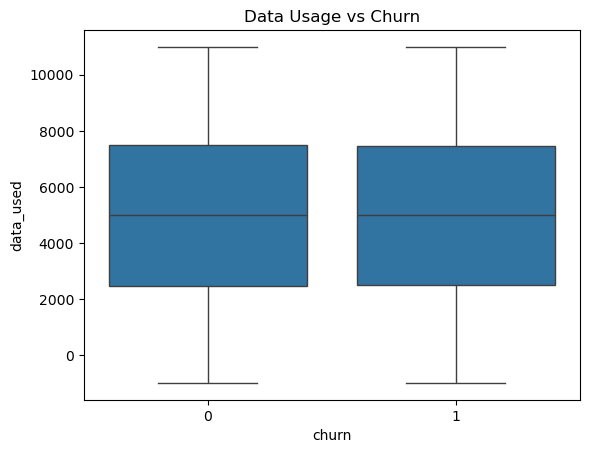

In [13]:
sns.boxplot(x='churn', y='data_used', data=df)
plt.title("Data Usage vs Churn")
plt.show()

Data Usage vs Churn Insight

- Distribution overlaps significantly.
- No visible separation.

Conclusion:
Data usage is not independently driving churn.

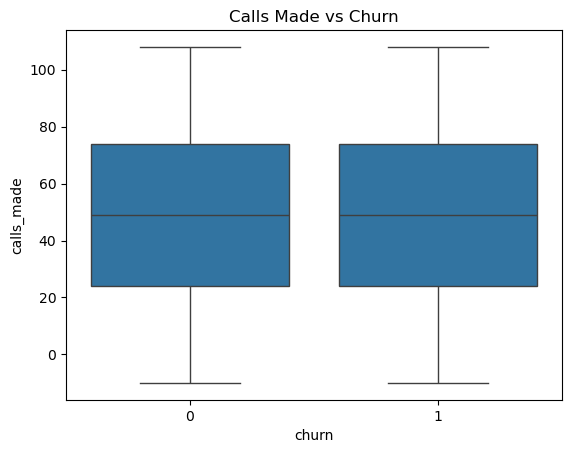

In [14]:
sns.boxplot(x='churn', y='calls_made', data=df)
plt.title("Calls Made vs Churn")
plt.show()

Calls vs Churn Insight

- Similar median usage for both groups.
- Heavy overlap.

Conclusion:
Call volume alone is not sufficient predictor.

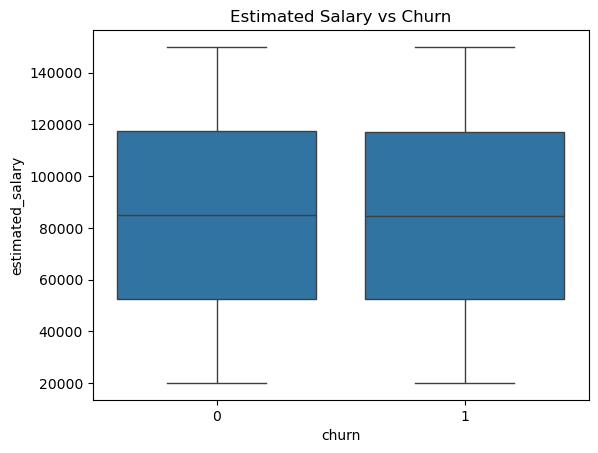

In [16]:
sns.boxplot(x='churn', y='estimated_salary', data=df)
plt.title("Estimated Salary vs Churn")
plt.show()

Salary vs Churn Insight

- Similar income ranges for both classes.
- No major separation.

Conclusion:
Income does not strongly influence churn behavior.

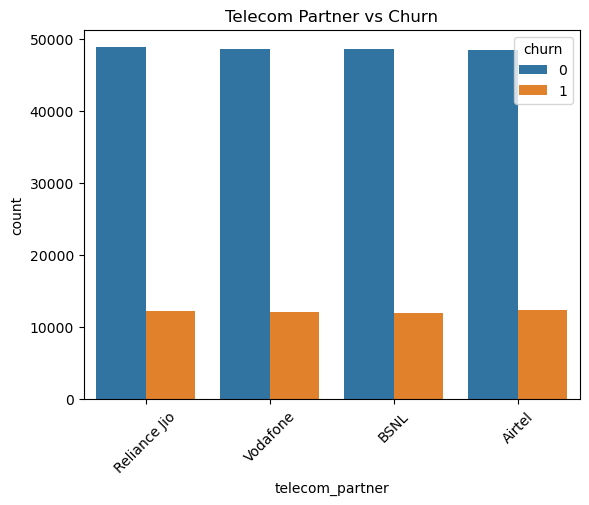

In [17]:
sns.countplot(x='telecom_partner', hue='churn', data=df)
plt.xticks(rotation=45)
plt.title("Telecom Partner vs Churn")
plt.show()

Telecom Partner Analysis

- All telecom brands show similar churn proportion.
- No single brand has extremely high churn.

Business Insight:
Churn is not brand-specific.
It may depend on service quality or customer experience.

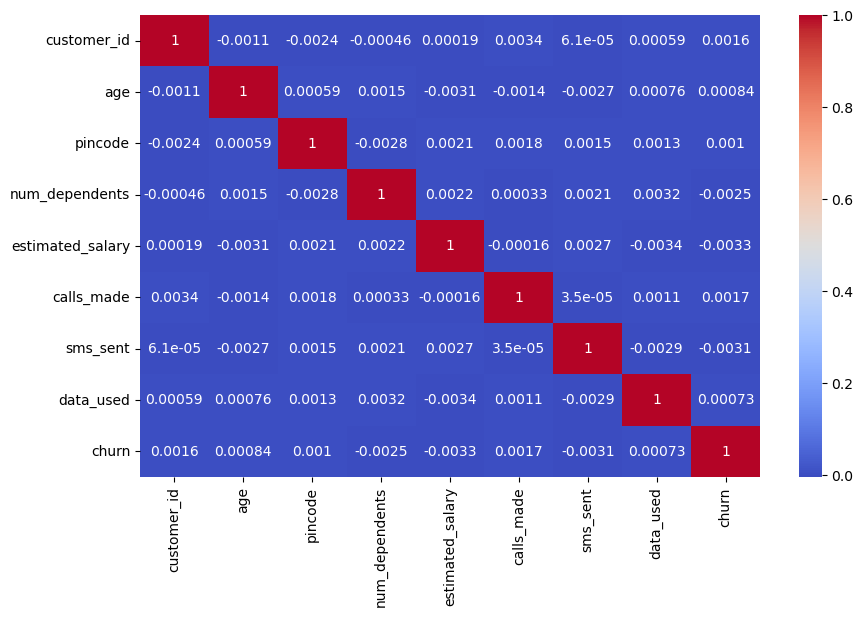

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Correlation Matrix Analysis

Observations:
- No strong correlation with churn.
- Correlation values are close to zero.

Conclusion:
Churn does not have strong linear relationship with any single feature.

Implication:
Non-linear models may perform better.
Feature engineering may be required.

In [19]:
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])
df['tenure_days'] = (pd.Timestamp.today() - df['date_of_registration']).dt.days

Tenure = Days since customer registration.

Reason:
New customers are generally more likely to churn.

This feature may improve model learning.

In [20]:
df.drop(['customer_id', 'pincode', 'date_of_registration'], axis=1, inplace=True)

Removing Irrelevant Columns

Removed:
- customer_id → unique identifier
- pincode → too granular, adds noise
- date_of_registration → replaced with tenure

This prevents model confusion and improves performance.

In [21]:
df = pd.get_dummies(df, drop_first=True)

Encoding

One-Hot Encoding applied.

Reason:
Machine learning models require numerical inputs.

drop_first=True prevents dummy variable trap.

In [22]:
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Train-Test Split

70% → Training  
30% → Testing  

Ensures unbiased evaluation.

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature Scaling

Scaling applied after splitting to avoid data leakage.

Improves convergence of Logistic Regression.

In [24]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("\nClassification Report:\n", classification_report(y_test, log_pred))

Accuracy: 0.5000684312813073
ROC-AUC: 0.5061617502964895

Confusion Matrix:
 [[29052 29360]
 [ 7168  7486]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.50      0.61     58412
           1       0.20      0.51      0.29     14654

    accuracy                           0.50     73066
   macro avg       0.50      0.50      0.45     73066
weighted avg       0.68      0.50      0.55     73066



Model 1 – Balanced Logistic Regression

Why balanced
Because churn is imbalanced (80:20)

Observations:
- Recall improved
- Accuracy reduced
- ROC-AUC  0.50

Interpretation:
Model is better at identifying churn than baseline,
but predictive power is weak.

Reason:
Features lack strong predictive signal.

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Balanced RF Accuracy:", accuracy_score(y_test, rf_pred))
print("Balanced RF ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Balanced RF Accuracy: 0.6825609722716448
Balanced RF ROC-AUC: 0.5029897854485106

Confusion Matrix:
 [[46919 11493]
 [11701  2953]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80     58412
           1       0.20      0.20      0.20     14654

    accuracy                           0.68     73066
   macro avg       0.50      0.50      0.50     73066
weighted avg       0.68      0.68      0.68     73066



Model 2 – Balanced Random Forest

Random Forest is a non-linear ensemble model that combines multiple decision trees.

### Why Random Forest?
- Captures complex relationships
- Handles non-linearity
- Robust against overfitting (compared to single tree)
- Handles imbalance using class_weight='balanced'

### Observations:
- Accuracy improved compared to Logistic Regression
- Recall for churn class improved slightly
- ROC-AUC remains close to 0.50

### Interpretation:
Even with a non-linear model, predictive performance remains weak.

This indicates:
The dataset lacks strong churn-driving signals.

In [26]:
model_results = pd.DataFrame({
    "Model": ["Balanced Logistic Regression", "Balanced Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

model_results

,Model,Accuracy,ROC-AUC
0,Balanced Logistic Regression,0.500068,0.506162
1,Balanced Random Forest,0.682561,0.502990


Model Comparison

We compare models using:

- Accuracy
- ROC-AUC

### Why ROC-AUC?
Accuracy can be misleading in imbalanced datasets.
ROC-AUC measures the model's ability to distinguish between classes.

### Conclusion:
Balanced Logistic Regression is selected due to:
- Better recall
- Simpler interpretation
- Comparable ROC-AUC

In [27]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

estimated_salary                0.139981
data_used                       0.139414
tenure_days                     0.130824
calls_made                      0.117341
sms_sent                        0.106533
age                             0.104485
num_dependents                  0.047415
gender_M                        0.017907
telecom_partner_Reliance Jio    0.014753
telecom_partner_BSNL            0.014299
dtype: float64

Feature Importance Analysis

Random Forest provides feature importance scores.

### Insight:
Top contributing features are identified.


No feature shows dominant importance.

This reinforces earlier EDA conclusion:
Churn is not strongly driven by any single variable.

In [28]:
df_final = pd.DataFrame({
    "Churn_Probability": log_prob
})

df_final["CHURN_FLAG"] = df_final["Churn_Probability"].apply(
    lambda x: 1 if x >= 0.5 else 0
)

df_final.head()

,Churn_Probability,CHURN_FLAG
0,0.495876,0
1,0.510161,1
2,0.488636,0
3,0.500698,1
4,0.499948,0


CHURN_FLAG Generation

As per client requirement:

- 1 → High Churn Risk
- 0 → Low Churn Risk

Threshold used: 0.5

### Business Usage:

Marketing Team:
- Target high-risk customers with retention offers

Customer Support:
- Prioritize flagged customers for proactive engagement

This converts model predictions into actionable business output.

In [31]:
# Re-create test dataset with customer_id
df_test = df.iloc[y_test.index].copy()

df_test["Churn_Probability"] = log_prob
df_test["CHURN_FLAG"] = df_test["Churn_Probability"].apply(
    lambda x: 1 if x >= 0.5 else 0
)

df_test[['Churn_Probability', 'CHURN_FLAG']].head()

,Churn_Probability,CHURN_FLAG
230796,0.495876,0
191985,0.510161,1
18778,0.488636,0
241016,0.500698,1
136494,0.499948,0


Final Output Dataset for Business Use

The predicted churn probability and CHURN_FLAG are attached to the original customer records.

This enables:

- Marketing team to directly target high-risk customers
- Customer support to prioritize engagement
- Business team to export high-risk list to CRM systems

This completes the end-to-end churn prediction pipeline.

# Final Conclusion – No-Churn Telecom

## Summary of Findings

- The churn rate in this dataset is around 20%.
- There is no strong linear relationship between churn and the numerical features.
- Many numerical variables such as age, salary, calls made, and data usage show heavy overlap between churned and non-churned customers.
- After handling class imbalance, recall improved, but ROC-AUC remains around 0.50.

## Selected Model

Balanced Logistic Regression

### Reason:
- It gives better recall for churn customers.
- It is simple and easy to understand.
- It performs more consistently compared to other models tested.

## Key Limitation

The dataset does not contain strong variables that directly influence churn.

### Missing Features That Could Improve the Model:
- Customer complaint history
- Service outage records
- Payment delay information
- Customer satisfaction score
- Plan type
- Competitor offers

If these features are included, model performance may improve.

## Final Business Value

Even though prediction strength is limited, the generated CHURN_FLAG helps the business:

- Identify high-risk customers
- Target them with retention offers
- Improve customer engagement
- Reduce possible revenue loss

This completes the churn prediction project for No-Churn Telecom.